In [61]:
# Gneral Imports

import os
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
import torch 
import torchvision
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
import cv2
import nibabel as nb


%matplotlib inline

In [62]:
base_folder = "/Volumes/Hard Drive/untitled folder/AV45"
base_path = Path(base_folder)
os.chdir(base_path)
print(os.getcwd())
files = (os.listdir())
print(len(files))

/Volumes/Hard Drive/untitled folder/AV45
779


In [63]:
AV45_folder = "/Users/SeanKelly1/Documents/FinalThesis(2023Ulster)/Raw/All/AV45"

if os.path.exists(AV45_folder):
    print("Folder already existed")
else:
    os.makedirs(AV45_folder)
    print("Folder created.")

class_names = [0.0, 0.5, 1.0, 2.0, 3.0]

for name in class_names:
    temp_folder_name = AV45_folder + "/" + str(name)
    if os.path.exists(temp_folder_name):
        pass
    else:
        os.makedirs(temp_folder_name)
        print("{} folder created.".format(name))

Folder already existed


In [64]:
print(os.getcwd())

/Volumes/Hard Drive/untitled folder/AV45


'/Volumes/Hard Drive/untitled folder/AV45/OAS30001_AV45_d2430/pet1/NIFTI'

In [159]:
file_name = os.listdir(base_folder)
# This is a folder and must be opened
# file_name = os.listdir(path)
print(file_name)

['.DS_Store', 'sub-OAS30122_ses-d0136_acq-AV45_pet.nii.gz', 'sub-OAS30143_ses-d3509_acq-AV45_pet.nii.gz', 'sub-OAS30143_ses-d4041_acq-AV45_pet.nii.gz', 'sub-OAS30146_ses-d2323_acq-AV45_pet.nii.gz', 'sub-OAS30149_ses-d1240_acq-AV45_pet.nii.gz', 'sub-OAS30151_ses-d64_acq-AV45_pet.nii.gz', 'sub-OAS30155_ses-d0785_acq-AV45_pet.nii.gz', 'sub-OAS30159_ses-d0110_acq-AV45_pet.nii.gz', 'sub-OAS30160_ses-d3534_acq-AV45_pet.nii.gz', 'sub-OAS30167_ses-d1340_acq-AV45_pet.nii.gz', 'sub-OAS30173_ses-d3841_acq-AV45_pet.nii.gz', 'sub-OAS30178_ses-d2455_acq-AV45_pet.nii.gz', 'sub-OAS30178_ses-d2794_acq-AV45_pet.nii.gz', 'sub-OAS30181_ses-d0058_acq-AV45_pet.nii.gz', 'sub-OAS30182_ses-d101_acq-AV45_pet.nii.gz', 'sub-OAS30182_ses-d1397_acq-AV45_pet.nii.gz', 'sub-OAS30184_ses-d3157_acq-AV45_pet.nii.gz', 'sub-OAS30185_ses-d4551_acq-AV45_pet.nii.gz', 'sub-OAS30185_ses-d6000_acq-AV45_run-04_pet.nii.gz', 'sub-OAS30187_ses-d0070_acq-AV45_pet.nii.gz', 'sub-OAS30187_ses-d1210_acq-AV45_run-04_pet.nii.gz', 'sub-OAS3

In [51]:
# Split the files in to sub folders to ease processing
# Create the folders first

print(len(os.listdir(base_folder))/10)

if os.path.exists(base_folder):
    print("Base Folder already existed")
else:
    os.makedirs(base_folder)
    print("Base Folder created.")

subfolder_names = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

for name in subfolder_names:
    temp_folder_name = base_folder + "/" + str(name)
    if os.path.exists(temp_folder_name):
        pass
    else:
        os.makedirs(temp_folder_name)
        print("{} folder created.".format(name))

79.0
Base Folder already existed


In [84]:
file_name

['.DS_Store',
 'sub-OAS30013_ses-d1216_acq-AV45_run-04_pet.nii.gz',
 'sub-OAS30021_ses-d0071_acq-AV45_pet.nii.gz',
 'sub-OAS30024_ses-d0084_acq-AV45_pet.nii.gz',
 'sub-OAS30025_ses-d2298_acq-AV45_pet.nii.gz',
 'sub-OAS30026_ses-d0696_acq-AV45_pet.nii.gz',
 'sub-OAS30026_ses-d129_acq-AV45_pet.nii.gz',
 'sub-OAS30028_ses-d1260_acq-AV45_pet.nii.gz',
 'sub-OAS30028_ses-d1847_acq-AV45_pet.nii.gz',
 'sub-OAS30036_ses-d1199_acq-AV45_pet.nii.gz',
 'sub-OAS30037_ses-d1307_acq-AV45_run-04_pet.nii.gz',
 'sub-OAS30038_ses-d5769_acq-AV45_run-04_pet.nii.gz',
 'sub-OAS30039_ses-d0103_acq-AV45_pet.nii.gz',
 'sub-OAS30042_ses-d0067_acq-AV45_pet.nii.gz',
 'sub-OAS30044_ses-d1319_acq-AV45_pet.nii.gz',
 'sub-OAS30044_ses-d61_acq-AV45_pet.nii.gz',
 'sub-OAS30046_ses-d1968_acq-AV45_pet.nii.gz',
 'sub-OAS30048_ses-d3375_acq-AV45_pet.nii.gz',
 'sub-OAS30048_ses-d3731_acq-AV45_pet.nii.gz',
 'sub-OAS30049_ses-d1633_acq-AV45_pet.nii.gz',
 'sub-OAS30049_ses-d2933_acq-AV45_run-04_pet.nii.gz',
 'sub-OAS30050_ses-d1

In [190]:
file_name = os.listdir(base_folder)
sub_parent_folder = '/Volumes/Hard Drive/untitled folder/'

n = 0
files_count = 0
for i in subfolder_names:
    current_folder = sub_parent_folder + str(i)
    files_count = 0
    while files_count < 79:
        each_file = file_name[n]
        file_to_replace = base_folder + "/" + each_file
        to_save = current_folder + "/" + each_file
        os.replace(Path(file_to_replace), Path(to_save))
        print(f"{each_file} files replaced")
        print(files_count)
        n += 1
        files_count = len(os.listdir(current_folder))
        print(files_count)

sub-OAS30002_ses-d2340_acq-AV45_pet.nii.gz files replaced
0
28
sub-OAS30003_ses-d2682_acq-AV45_pet.nii.gz files replaced
28
29
sub-OAS30003_ses-d3731_acq-AV45_pet.nii.gz files replaced
29
30
sub-OAS30004_ses-d2232_acq-AV45_pet.nii.gz files replaced
30
31
sub-OAS30004_ses-d3457_acq-AV45_pet.nii.gz files replaced
31
32
sub-OAS30005_ses-d2384_acq-AV45_pet.nii.gz files replaced
32
33
sub-OAS30005_ses-d3453_acq-AV45_pet.nii.gz files replaced
33
34
sub-OAS30006_ses-d2342_acq-AV45_pet.nii.gz files replaced
34
35
sub-OAS30006_ses-d3386_acq-AV45_pet.nii.gz files replaced
35
36
sub-OAS30007_ses-d1636_acq-AV45_pet.nii.gz files replaced
36
37
sub-OAS30007_ses-d2722_acq-AV45_pet.nii.gz files replaced
37
38
sub-OAS30008_ses-d1327_acq-AV45_pet.nii.gz files replaced
38
39
sub-OAS30008_ses-d2035_acq-AV45_pet.nii.gz files replaced
39
40
sub-OAS30008_ses-d3336_acq-AV45_run-04_pet.nii.gz files replaced
40
41
sub-OAS30010_ses-d0068_acq-AV45_pet.nii.gz files replaced
41
42
sub-OAS30010_ses-d1514_acq-AV45_ru

IndexError: list index out of range

In [191]:
for i in subfolder_names:
    current_folder = sub_parent_folder + str(i)
    print(len(os.listdir(current_folder)))

79
80
80
80
80
80
80
80
80
60


In [196]:
n = 0

folder = sub_parent_folder + str(1)
os.chdir(folder)
file_name = os.listdir(folder)
for temp in file_name:
    print(temp)
    if temp != '.DS_Store':
        tensor_nifti = nb.load(temp) # The pics is extracted but remains in a nibabel object
        temp_arr = tensor_nifti.get_fdata() # Converts the nibabel object to numpy array
        print(temp_arr.shape, temp)
        # if len(temp_arr.shape) > 3:
        #     if temp_arr.shape[3] > 25:
        n += 1
print(n)

.DS_Store
sub-OAS30002_ses-d2340_acq-AV45_pet.nii.gz
(256, 256, 127, 26) sub-OAS30002_ses-d2340_acq-AV45_pet.nii.gz
sub-OAS30003_ses-d2682_acq-AV45_pet.nii.gz
(256, 256, 127, 26) sub-OAS30003_ses-d2682_acq-AV45_pet.nii.gz
sub-OAS30003_ses-d3731_acq-AV45_pet.nii.gz
(256, 256, 127, 26) sub-OAS30003_ses-d3731_acq-AV45_pet.nii.gz
sub-OAS30004_ses-d2232_acq-AV45_pet.nii.gz
(344, 344, 127, 4) sub-OAS30004_ses-d2232_acq-AV45_pet.nii.gz
sub-OAS30004_ses-d3457_acq-AV45_pet.nii.gz
(256, 256, 127, 26) sub-OAS30004_ses-d3457_acq-AV45_pet.nii.gz
sub-OAS30005_ses-d2384_acq-AV45_pet.nii.gz
(256, 256, 127, 26) sub-OAS30005_ses-d2384_acq-AV45_pet.nii.gz
sub-OAS30005_ses-d3453_acq-AV45_pet.nii.gz
(256, 256, 127, 4) sub-OAS30005_ses-d3453_acq-AV45_pet.nii.gz
sub-OAS30006_ses-d2342_acq-AV45_pet.nii.gz
(256, 256, 127, 26) sub-OAS30006_ses-d2342_acq-AV45_pet.nii.gz
sub-OAS30006_ses-d3386_acq-AV45_pet.nii.gz
(256, 256, 127, 4) sub-OAS30006_ses-d3386_acq-AV45_pet.nii.gz
sub-OAS30007_ses-d1636_acq-AV45_pet.nii

In [18]:
temp_arr.shape


# The first 2 rep the image width and height 
# The third reps length accross the patient 
# The fourth is the time frame for each length  

(256, 256, 127, 26)

## We pick 60 - 80 for the last 20 timestamp

In [11]:
images = []
for i in range(20):
    temp = temp_arr[:, :, 70, i]
    images.append(temp)


plt.figure(figsize=(50, 50))
i = 1
for image in images:
    plt.subplot(5, 4, i)
    plt.imshow(image)
    i += 1
    

NameError: name 'temp_arr' is not defined

In [219]:
base_folder = '/Volumes/Hard Drive/untitled folder/AV45'
processed_folder = "/Users/SeanKelly1/Documents/FinalThesis(2023Ulster)/Raw/All/AV45"
adrc_folder = "/Users/SeanKelly1/Documents/FinalThesis(2023Ulster)/Spreadsheet/ADRC Clinical Data.csv"
os.chdir(base_folder)


folder = sub_parent_folder + str(10)
os.chdir(folder)
file_av45 = os.listdir(folder)
n = 0
done_list = []
skipped_list = []
for av45 in file_av45:
    temp_img = []
    if av45 == ".DS_Store" or av45 in done_list or av45 in skipped_list or cdr == None:
        pass
    else:
        tensor_nifti = nb.load(av45) # The pics is extracted but remains in a nibabel object
        temp_arr = tensor_nifti.get_fdata() # Converts the nibabel object to numpy array
        if len(temp_arr.shape) != 4 or temp_arr.shape[3] < 26 or temp_arr.shape[2] < 127:
            skipped_list.append(av45)
            print("passed")
            pass
        else:
            try:
                # sub-OAS30003_ses-d2682_acq-AV45_pet.nii.gz
                subject_id = av45.split("-")[1].split("_")[0]
                assessement_id = av45.split("-")[2].split("_")[0]
                typ = av45.split("-")[-1].split("_")[0]
                raw_df = pd.read_csv(adrc_folder)
                cdr = max(raw_df[raw_df["Subject"] == subject_id]["cdr"])
                new_file_name = "{}_{}_{}".format(subject_id, typ, cdr)
                
                for i in range(6, 26):
                    for y in range(60, 81):
                        temp = temp_arr[:, :, y, i]
                        new_file_name = "{}_{}_{}_{}_{}".format(subject_id, typ, cdr, y, i)
                        temp_folder = (processed_folder + "/" + str(cdr) + "/" + new_file_name + ".png")
                        plt.imsave(temp_folder, temp)
                        print("{} has been processed".format(av45))
                        n += 1
                done_list.append(av45)
            except:
                skipped_list.append(av45)
                pass
    
                
print("{} images saved and classified by cdr".format(n))

print(skipped_list)


print(done_list)

sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS30093_ses-d1192_acq-AV45_pet.nii.gz has been processed
sub-OAS3

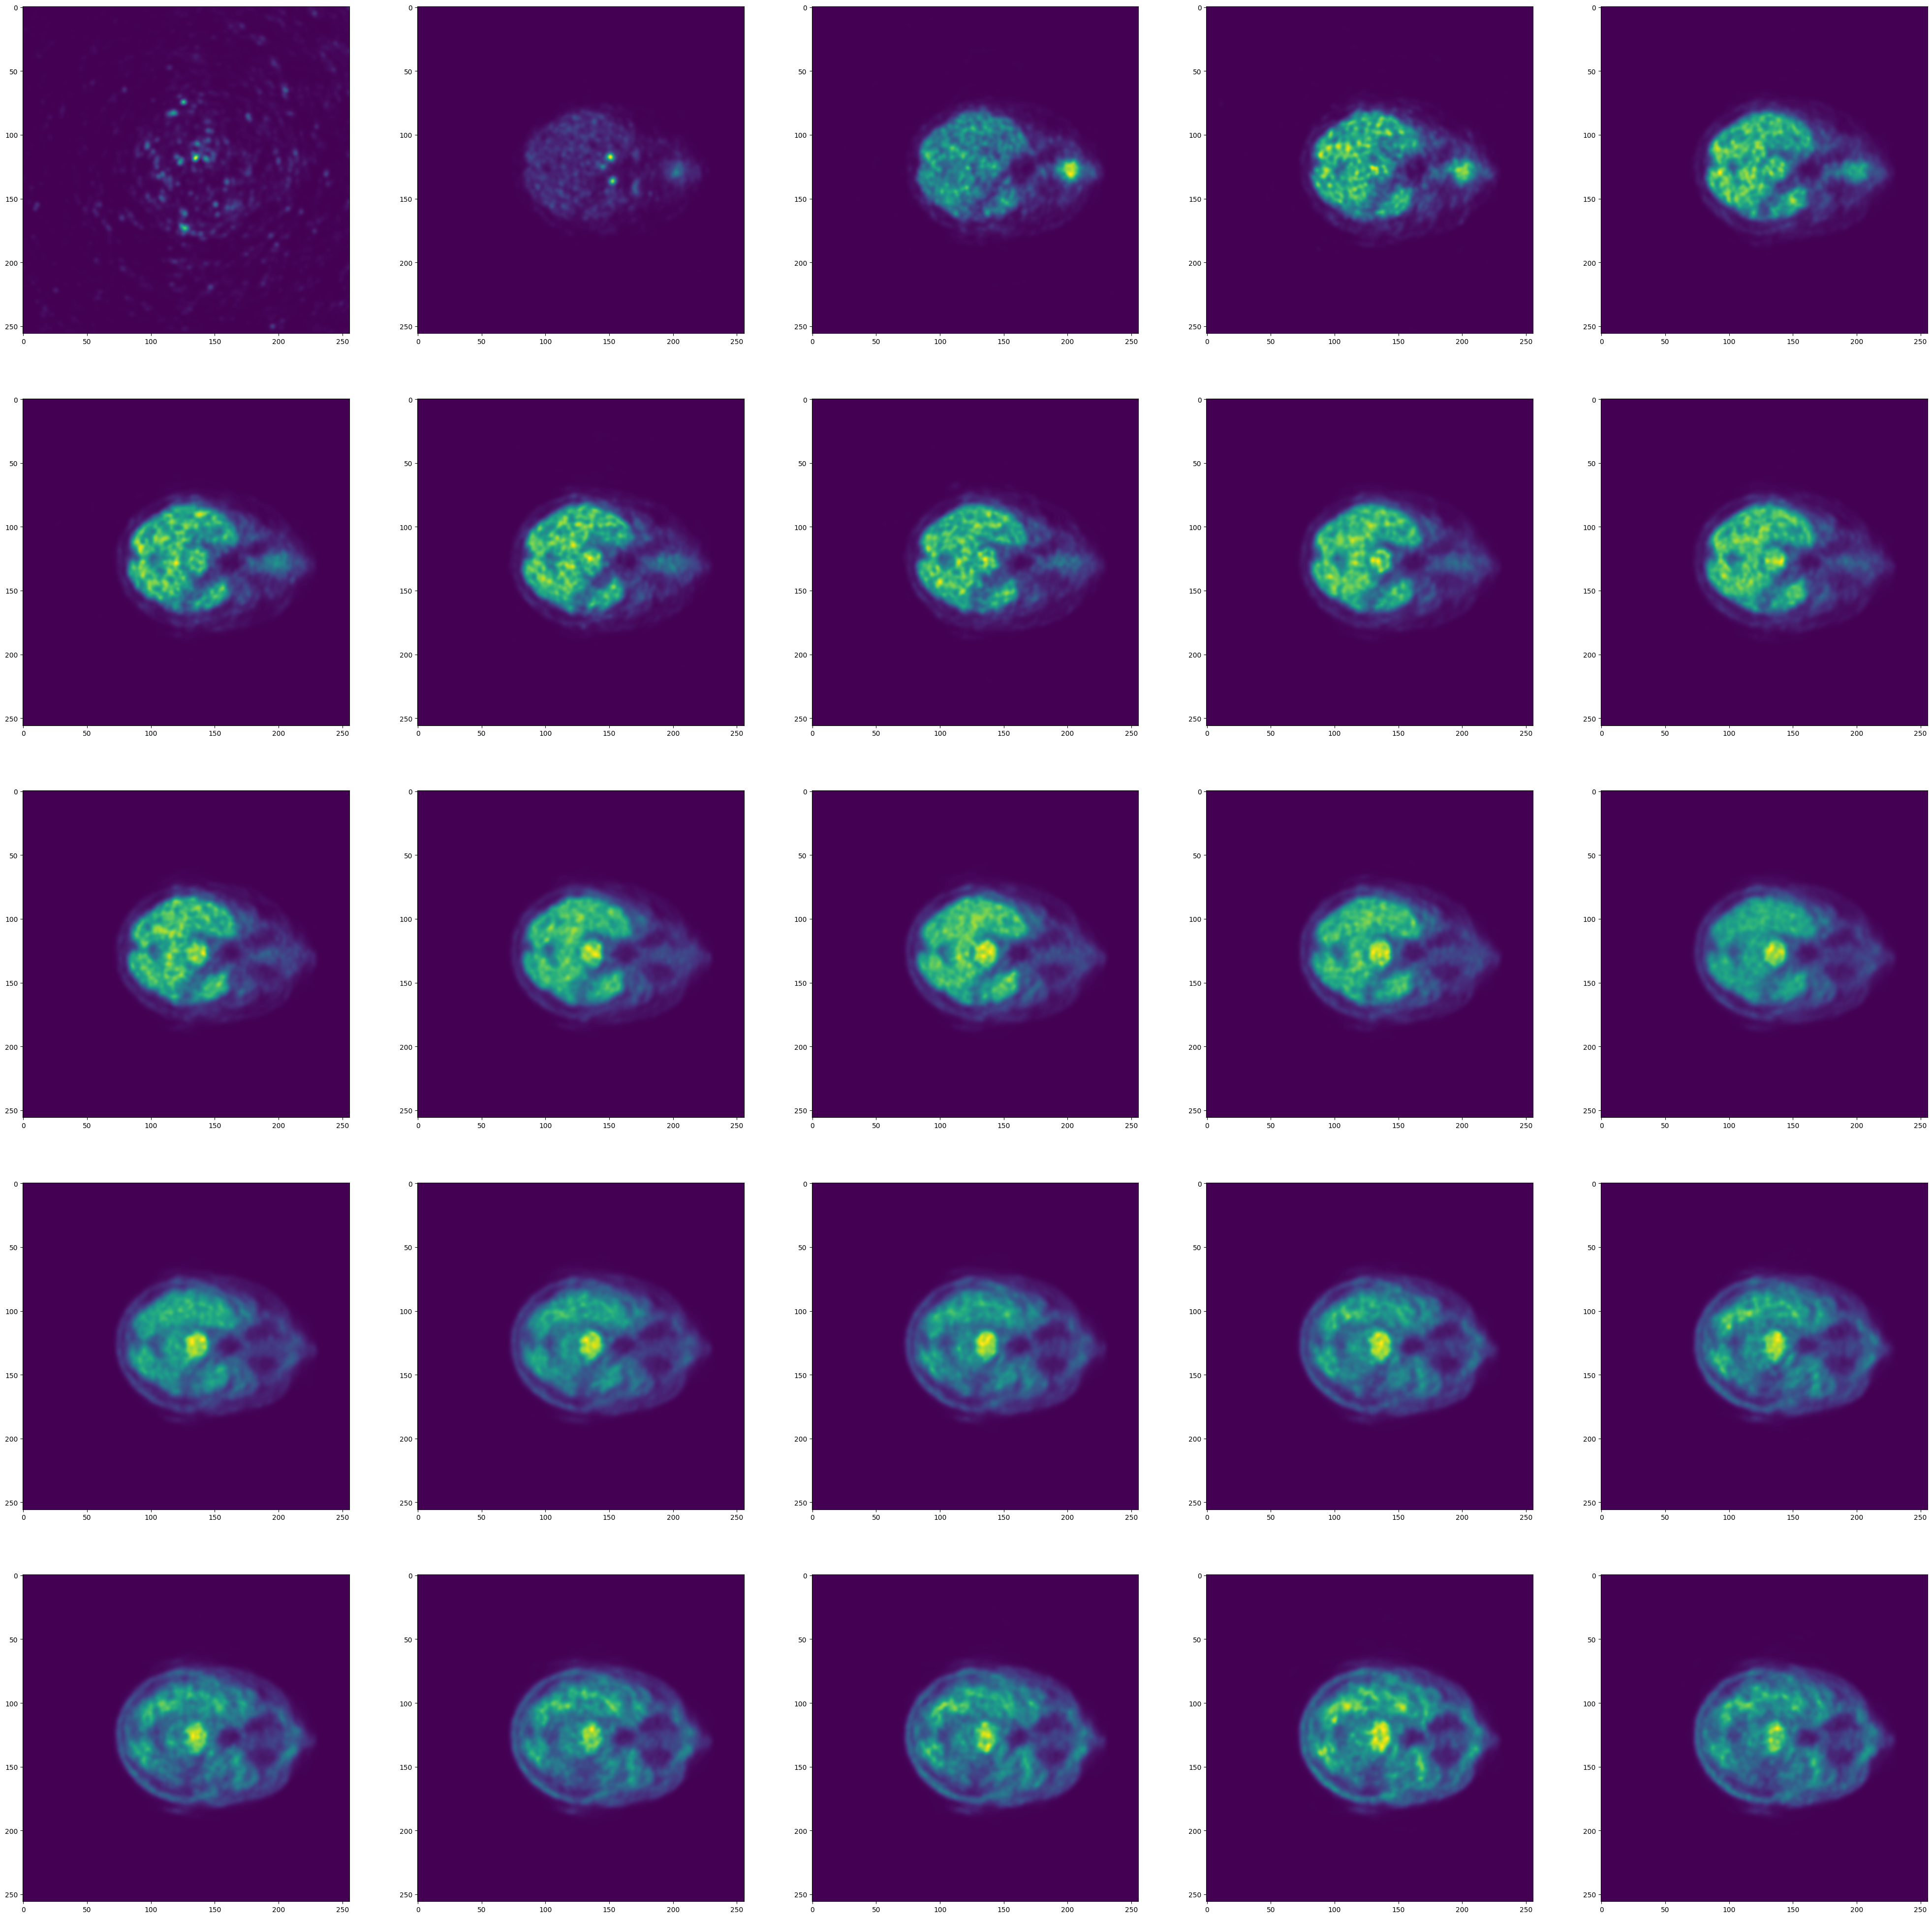

In [125]:
images = []
for i in range(25):
    temp = temp_arr[:, :, 45, i]
    images.append(temp)


plt.figure(figsize=(50, 50))
i = 1
for image in images:
    plt.subplot(5, 5, i)
    plt.imshow(image)
    i += 1
    

In [210]:
print(len(done_list))

54


In [202]:
print(done_list)

['sub-OAS30002_ses-d2340_acq-AV45_pet.nii.gz', 'sub-OAS30003_ses-d2682_acq-AV45_pet.nii.gz', 'sub-OAS30003_ses-d3731_acq-AV45_pet.nii.gz', 'sub-OAS30004_ses-d3457_acq-AV45_pet.nii.gz', 'sub-OAS30005_ses-d2384_acq-AV45_pet.nii.gz', 'sub-OAS30006_ses-d2342_acq-AV45_pet.nii.gz', 'sub-OAS30007_ses-d1636_acq-AV45_pet.nii.gz', 'sub-OAS30007_ses-d2722_acq-AV45_pet.nii.gz', 'sub-OAS30008_ses-d1327_acq-AV45_pet.nii.gz', 'sub-OAS30010_ses-d0068_acq-AV45_pet.nii.gz', 'sub-OAS30013_ses-d0102_acq-AV45_pet.nii.gz', 'sub-OAS30013_ses-d1216_acq-AV45_run-04_pet.nii.gz', 'sub-OAS30024_ses-d0084_acq-AV45_pet.nii.gz', 'sub-OAS30025_ses-d2298_acq-AV45_pet.nii.gz', 'sub-OAS30026_ses-d0696_acq-AV45_pet.nii.gz', 'sub-OAS30026_ses-d129_acq-AV45_pet.nii.gz', 'sub-OAS30028_ses-d1260_acq-AV45_pet.nii.gz', 'sub-OAS30028_ses-d1847_acq-AV45_pet.nii.gz', 'sub-OAS30036_ses-d1199_acq-AV45_pet.nii.gz', 'sub-OAS30037_ses-d1307_acq-AV45_run-04_pet.nii.gz', 'sub-OAS30038_ses-d5769_acq-AV45_run-04_pet.nii.gz', 'sub-OAS30039

In [203]:
'sub-OAS30002_ses-d2340_acq-AV45_pet.nii.gz' in done_list

True